---
title: "Module 5 Assignment: Machine Learning on Scale"
author:
  - name: Julie Ngo Tran
    affiliations:
      - id: bu
        name: Boston University
        city: Boston
        state: MA
number-sections: true
date: today
format:
  html:
    toc: true
date-modified: today
date-format: long
execute:
  echo: true
  eval: true
  freeze: auto
---


**GitHub repository:** <https://github.com/AD688-SP26/a05-sum26-frjulie8-proj>

## System Information {.unnumbered}

In [1]:
# | eval: true
# | echo: true
import platform
import psutil

def get_processor():
    """platform.processor() is empty on Linux, so fall back to /proc/cpuinfo."""
    name = platform.processor()
    if not name:
        try:
            with open("/proc/cpuinfo") as f:
                for line in f:
                    if "model name" in line:
                        name = line.split(":", 1)[1].strip()
                        break
        except FileNotFoundError:
            pass
    return name or "Unknown"


print("Operating System:", platform.system(), platform.release())
print("Python Version:", platform.python_version())
print("Machine:", platform.machine())
print("Processor:", get_processor())

mem = psutil.virtual_memory()
print("Total Memory (MB):", round(mem.total / (1024**2), 2))
print("Available Memory (MB):", round(mem.available / (1024**2), 2))

Operating System: Linux 7.0.0-1006-aws
Python Version: 3.14.4
Machine: x86_64
Processor: Intel(R) Xeon(R) Platinum 8259CL CPU @ 2.50GHz
Total Memory (MB): 7815.46
Available Memory (MB): 4957.06


# Load the Dataset

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression, GeneralizedLinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import numpy as np

np.random.seed(42)

spark = (SparkSession.builder.appName("LightcastSalaryML")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

df = (spark.read
      .option("header", "true")
      .option("inferSchema", "true")
      .option("multiLine", "true")
      .option("escape", "\"")
      .csv("data/lightcast_job_postings.csv"))

# Diagnostic check (commented out for the rendered submission).
# df.printSchema()
# df.show(5)
print("Total rows loaded:", df.count())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/20 14:58:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Total rows loaded: 72498


The raw Lightcast file loads with over seventy thousand job postings and roughly one hundred and thirty columns describing each posting. Most of those columns are identifiers, free text, or geographic codes that are not useful for predicting pay, so the next step narrows the data down to a small set of columns that have a plausible economic relationship with salary.

# Feature Engineering

We predict the advertised SALARY using four numeric inputs and two categorical inputs. The numeric inputs are minimum years of experience, posting duration, an engineered remote indicator, and a staffing agency indicator. The categorical inputs are the minimum required education level and the employment type. Minimum years of experience is required by the assignment and is also the variable we later square to build the polynomial model. We use the single minimum education field rather than the combined education list because the single field has only six clean levels, which keeps the one hot encoded vector small and the coefficient table readable and avoids the rare sparse categories that otherwise make the standard error calculation unstable. We considered adding job location, but median advertised salary is almost flat across the four United States regions in this data and adding the high cardinality location column removed the model's ability to report standard errors, so location is documented here as tested and excluded rather than used.

In [3]:
# Engineer two binary indicators used as numeric inputs.
df = df.withColumn(
    "IS_REMOTE",
    F.when(F.col("REMOTE_TYPE_NAME").isin("Remote", "Hybrid Remote"), 1).otherwise(0)
)
df = df.withColumn(
    "STAFFING",
    F.when(F.col("COMPANY_IS_STAFFING") == True, 1).otherwise(0)
)

numeric_cols = ["MIN_YEARS_EXPERIENCE", "DURATION", "IS_REMOTE", "STAFFING"]
categorical_cols = ["MIN_EDULEVELS_NAME", "EMPLOYMENT_TYPE_NAME"]
target = "SALARY"

# Drop rows missing the target or any modelling input (the two indicators are never null by construction).
model_df = df.dropna(subset=[target, "MIN_YEARS_EXPERIENCE", "DURATION"] + categorical_cols)
print("Rows available for modelling:", model_df.count())

Rows available for modelling: 14416


In [4]:
# Index then one hot encode each categorical column.
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx")
            for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec")
            for c in categorical_cols]

# Assemble the standard feature vector used by the linear and random forest models.
assembler = VectorAssembler(
    inputCols=numeric_cols + [c + "_vec" for c in categorical_cols],
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler])
data = pipeline.fit(model_df).transform(model_df)

In [5]:
# Polynomial term: square the minimum years of experience, then assemble features_poly.
data = data.withColumn("MIN_YEARS_EXPERIENCE_SQ",
                       F.col("MIN_YEARS_EXPERIENCE") * F.col("MIN_YEARS_EXPERIENCE"))

poly_numeric = ["MIN_YEARS_EXPERIENCE", "MIN_YEARS_EXPERIENCE_SQ",
                "DURATION", "IS_REMOTE", "STAFFING"]
assembler_poly = VectorAssembler(
    inputCols=poly_numeric + [c + "_vec" for c in categorical_cols],
    outputCol="features_poly"
)
data = assembler_poly.transform(data)

data.select("SALARY", "features", "features_poly").show(5, truncate=False)

+------+----------------------------------------------+---------------------------------------------------+
|SALARY|features                                      |features_poly                                      |
+------+----------------------------------------------+---------------------------------------------------+
|192800|(11,[0,1,4,9],[6.0,55.0,1.0,1.0])             |(12,[0,1,2,5,10],[6.0,36.0,55.0,1.0,1.0])          |
|125900|(11,[0,1,7,9],[12.0,18.0,1.0,1.0])            |(12,[0,1,2,8,10],[12.0,144.0,18.0,1.0,1.0])        |
|118560|[5.0,20.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0]|[5.0,25.0,20.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0]|
|192800|(11,[0,1,4,9],[6.0,55.0,1.0,1.0])             |(12,[0,1,2,5,10],[6.0,36.0,55.0,1.0,1.0])          |
|116500|(11,[0,1,7,9],[12.0,16.0,1.0,1.0])            |(12,[0,1,2,8,10],[12.0,144.0,16.0,1.0,1.0])        |
+------+----------------------------------------------+---------------------------------------------------+
only showing top 5 rows


The output shows each posting reduced to two sparse feature vectors. The features column holds the inputs for the linear and random forest models, while features_poly adds the squared experience term in the second position so that the polynomial model can capture a curved relationship between experience and pay. Both vectors store only the non zero entries, which is why the printed values list positions and amounts rather than a long dense row.

# Train/Test Split

We split the modelling data into eighty percent for training and twenty percent for testing using a fixed random seed of forty two. The eighty twenty split is a common default that leaves enough data to estimate the model coefficients reliably while still holding back a meaningful test sample for an honest performance estimate. Fixing the seed makes the split reproducible, so every run of the notebook produces the same training and testing rows and the same reported metrics.

In [6]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)
print("Training set:", (train_data.count(), len(train_data.columns)))
print("Testing set:", (test_data.count(), len(test_data.columns)))

Training set: (11604, 140)


Testing set: (2812, 140)


# Linear Regression

Before fitting the final model we document the important issue that appears when both minimum and maximum years of experience are used together. In this filtered data the two columns are perfectly correlated, which makes the feature matrix singular and prevents the model from reporting standard errors. This is a classic case of perfect multicollinearity, where the model cannot decide how to divide a shared effect between two identical predictors. The cell below demonstrates the failure and confirms the cause, after which we proceed with the corrected feature set that excludes maximum years of experience. We fit the regression as a Gaussian generalized linear model with an identity link, which is mathematically the same as ordinary least squares but additionally reports the AIC and deviance values that the final model comparison section relies on.

In [7]:
demo_df = model_df.dropna(subset=["MAX_YEARS_EXPERIENCE"])
print("Correlation between MIN and MAX years experience:",
      round(demo_df.stat.corr("MIN_YEARS_EXPERIENCE", "MAX_YEARS_EXPERIENCE"), 4))

demo = VectorAssembler(inputCols=["MIN_YEARS_EXPERIENCE", "MAX_YEARS_EXPERIENCE"],
                       outputCol="demo_features").transform(demo_df)
demo_model = GeneralizedLinearRegression(featuresCol="demo_features", labelCol="SALARY",
                                         family="gaussian", link="identity").fit(demo)
try:
    _ = demo_model.summary.coefficientStandardErrors
    print("Standard errors were available.")
except Exception as e:
    print("Standard errors unavailable:", type(e).__name__)
    print("Cause: MIN and MAX years experience are perfectly collinear, so the matrix is singular.")

Correlation between MIN and MAX years experience: 1.0


Standard errors unavailable: UnsupportedOperationException
Cause: MIN and MAX years experience are perfectly collinear, so the matrix is singular.


In [8]:
# Fit a Gaussian GLM with identity link on the corrected feature vector.
# This is ordinary linear regression, but the GLM summary also reports AIC and deviance.
glr = GeneralizedLinearRegression(featuresCol="features", labelCol="SALARY",
                                  family="gaussian", link="identity")
lr_model = glr.fit(train_data)
train_sum = lr_model.summary

# The GLM summary does not expose R2/RMSE/MAE, so evaluate predictions on the test set.
lr_pred = lr_model.transform(test_data)
lr_r2 = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="r2").evaluate(lr_pred)
lr_rmse = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="rmse").evaluate(lr_pred)
lr_mae = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="mae").evaluate(lr_pred)

print("Intercept:", round(lr_model.intercept, 2))
print("Test R2:", round(lr_r2, 4))
print("Test RMSE:", round(lr_rmse, 2))
print("Test MAE:", round(lr_mae, 2))
print("AIC:", round(train_sum.aic, 2))
print("Deviance:", round(train_sum.deviance, 2))

Intercept: 91997.89
Test R2: 0.3671
Test RMSE: 33687.69
Test MAE: 26097.17


AIC: 274851.98
Deviance: 13117343398956.03


In [9]:
# Recover the expanded feature names from the assembled vector metadata.
def feature_names(dframe, col="features"):
    attrs = dframe.schema[col].metadata["ml_attr"]["attrs"]
    size = dframe.select(col).first()[0].size
    names = [None] * size
    for group in attrs.values():
        for a in group:
            names[a["idx"]] = a["name"]
    return names

names = feature_names(data, "features")

estimates = list(lr_model.coefficients) + [lr_model.intercept]
se = list(train_sum.coefficientStandardErrors)
tvals = list(train_sum.tValues)
pvals = list(train_sum.pValues)
labels = names + ["Intercept"]

# Diagnostic check (lengths should all match).
print("Length of features:", len(labels))
print("Length of coefs:", len(estimates))
print("Length of se:", len(se))
print("Length of tvals:", len(tvals))
print("Length of pvals:", len(pvals))

coef_table = pd.DataFrame({
    "Feature": labels,
    "Estimate": estimates,
    "Std Error": se,
    "t-stat": tvals,
    "P-Value": pvals,
})
coef_table["CI Lower"] = coef_table["Estimate"] - 1.96 * coef_table["Std Error"]
coef_table["CI Upper"] = coef_table["Estimate"] + 1.96 * coef_table["Std Error"]
coef_table = coef_table.round(4)
coef_table

Length of features: 12
Length of coefs: 12
Length of se: 12
Length of tvals: 12
Length of pvals: 12


,Feature,Estimate,Std Error,t-stat,P-Value,CI Lower,CI Upper
0,MIN_YEARS_EXPERIENCE,7413.5735,99.9345,74.1843,0.0000,7217.7018,7609.4452
1,DURATION,-6.6928,21.8982,-0.3056,0.7599,-49.6133,36.2277
2,IS_REMOTE,-260.4417,714.0899,-0.3647,0.7153,-1660.0579,1139.1745
3,STAFFING,-1406.9133,998.7776,-1.4086,0.1590,-3364.5174,550.6909
4,MIN_EDULEVELS_NAME_vec_Bachelor's degree,-13127.8879,8494.1728,-1.5455,0.1222,-29776.4665,3520.6907
5,MIN_EDULEVELS_NAME_vec_No Education Listed,-10186.0082,8519.4989,-1.1956,0.2319,-26884.2259,6512.2096
6,MIN_EDULEVELS_NAME_vec_High school or GED,-44981.4970,8566.4666,-5.2509,0.0000,-61771.7716,-28191.2225
7,MIN_EDULEVELS_NAME_vec_Associate degree,-45579.9453,8590.8124,-5.3057,0.0000,-62417.9377,-28741.9530
8,MIN_EDULEVELS_NAME_vec_Master's degree,30329.1695,8705.3344,3.4840,0.0005,13266.7140,47391.6250
9,EMPLOYMENT_TYPE_NAME_vec_Full-time (> 32 hours),3865.5071,2668.2788,1.4487,0.1475,-1364.3194,9095.3336


## Linear Regression Summary

The fitted model now reports standard errors, t statistics, and p values for every coefficient, which confirms that dropping the redundant maximum experience column restored a full rank feature matrix. Each estimate is read as the change in predicted annual salary in United States dollars for a one unit change in that feature while the others are held constant, and a feature is treated as statistically significant when its p value falls below the conventional five percent threshold. Minimum years of experience is by far the most important predictor, with each additional required year associated with about seven thousand four hundred United States dollars of additional salary at a t statistic above seventy four and a p value below one in ten thousand, so the effect is both large and highly reliable. The education requirements move salary in sensible ways relative to the doctoral and professional degree baseline, which is the smallest group in the data and so is best read as a broad reference rather than a precise one, in that requiring only a high school credential or an associate degree is associated with roughly forty five thousand United States dollars less while requiring a master's degree is associated with about thirty thousand dollars more, and all three of these effects are statistically significant. By contrast the posting duration, the remote indicator, the staffing indicator, and the employment type are all statistically insignificant, which tells us that once experience and education are accounted for these factors add little explanatory power. The model explains about thirty seven percent of the variation in salary on the held out test data with a typical prediction error of roughly thirty three thousand seven hundred United States dollars, a moderate fit that reflects how much of advertised pay depends on role, company, and skills that these few structured columns do not capture, and these values form the baseline that the polynomial and random forest models are measured against.

# Polynomial Regression

The polynomial model uses the features_poly vector, which adds the squared minimum years of experience term to the linear inputs. The squared term lets the model bend the experience to salary relationship rather than forcing it to be a straight line, which is useful if pay rises quickly for early career experience and then levels off for senior roles. The linear and squared experience terms are correlated by construction, so this is a milder version of the multicollinearity issue seen earlier, but because the squared term is not an exact copy of the linear term the feature matrix stays full rank and the model still reports standard errors.

In [10]:
# Fit the polynomial model as a Gaussian GLM so its summary also reports AIC and deviance.
poly_glr = GeneralizedLinearRegression(featuresCol="features_poly", labelCol="SALARY",
                                       family="gaussian", link="identity")
poly_model = poly_glr.fit(train_data)
poly_train_sum = poly_model.summary

poly_pred = poly_model.transform(test_data)
poly_r2 = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="r2").evaluate(poly_pred)
poly_rmse = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="rmse").evaluate(poly_pred)
poly_mae = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="mae").evaluate(poly_pred)

print("Intercept:", round(poly_model.intercept, 2))
print("Test R2:", round(poly_r2, 4))
print("Test RMSE:", round(poly_rmse, 2))
print("Test MAE:", round(poly_mae, 2))
print("AIC:", round(poly_train_sum.aic, 2))
print("Deviance:", round(poly_train_sum.deviance, 2))

Intercept: 86446.5
Test R2: 0.3771
Test RMSE: 33419.7
Test MAE: 25732.77


AIC: 274693.59
Deviance: 12937276428055.14


In [11]:
poly_names = feature_names(data, "features_poly")

poly_estimates = list(poly_model.coefficients) + [poly_model.intercept]
poly_se = list(poly_train_sum.coefficientStandardErrors)
poly_tvals = list(poly_train_sum.tValues)
poly_pvals = list(poly_train_sum.pValues)
poly_labels = poly_names + ["Intercept"]

# Diagnostic check (lengths should all match).
print("Length of features:", len(poly_labels))
print("Length of coefs:", len(poly_estimates))
print("Length of se:", len(poly_se))
print("Length of tvals:", len(poly_tvals))
print("Length of pvals:", len(poly_pvals))

poly_table = pd.DataFrame({
    "Feature": poly_labels,
    "Estimate": poly_estimates,
    "Std Error": poly_se,
    "t-stat": poly_tvals,
    "P-Value": poly_pvals,
})
poly_table["CI Lower"] = poly_table["Estimate"] - 1.96 * poly_table["Std Error"]
poly_table["CI Upper"] = poly_table["Estimate"] + 1.96 * poly_table["Std Error"]
poly_table = poly_table.round(4)
poly_table

Length of features: 13
Length of coefs: 13
Length of se: 13
Length of tvals: 13
Length of pvals: 13


,Feature,Estimate,Std Error,t-stat,P-Value,CI Lower,CI Upper
0,MIN_YEARS_EXPERIENCE,11577.5959,342.5307,33.8002,0.0000,10906.2357,12248.9561
1,MIN_YEARS_EXPERIENCE_SQ,-319.9816,25.1924,-12.7015,0.0000,-369.3587,-270.6046
2,DURATION,-10.6199,21.7505,-0.4883,0.6254,-53.2509,32.0111
3,IS_REMOTE,-81.1831,709.3427,-0.1144,0.9089,-1471.4948,1309.1285
4,STAFFING,-1649.8043,992.1257,-1.6629,0.0964,-3594.3708,294.7621
5,MIN_EDULEVELS_NAME_vec_Bachelor's degree,-15149.4154,8437.5349,-1.7955,0.0726,-31686.9838,1388.1531
6,MIN_EDULEVELS_NAME_vec_No Education Listed,-11960.2167,8462.3394,-1.4133,0.1576,-28546.4020,4625.9685
7,MIN_EDULEVELS_NAME_vec_High school or GED,-47062.8737,8509.4107,-5.5307,0.0000,-63741.3188,-30384.4287
8,MIN_EDULEVELS_NAME_vec_Associate degree,-42780.4943,8534.8582,-5.0124,0.0000,-59508.8164,-26052.1721
9,MIN_EDULEVELS_NAME_vec_Master's degree,29337.1522,8646.1029,3.3931,0.0007,12390.7906,46283.5138


## Polynomial Regression Summary

The polynomial model adds the squared minimum experience term so that the marginal effect of an extra year of required experience is allowed to change as experience grows. The estimates show exactly the shape we expected, with the linear experience term large and positive at about eleven thousand six hundred United States dollars per year and the squared term negative at about minus three hundred and twenty dollars, and the squared term is highly significant with a t statistic near minus thirteen and a p value below one in ten thousand. A positive linear term paired with a significant negative squared term means salary rises steeply with early experience but each additional year adds less, the classic pattern of diminishing returns at senior levels. Setting the marginal effect to zero shows that predicted salary stops rising at roughly eighteen years of required experience and then gently turns down, which is a sensible ceiling for advertised pay. The education and other coefficients keep the same signs and significance as in the linear model, so adding the curve does not disturb the rest of the story. On the held out test data the polynomial model reaches an R squared of about thirty eight percent with a typical error near thirty three thousand four hundred United States dollars, a small but genuine improvement over the plain linear model, and because the squared term is strongly significant the added complexity is justified rather than gratuitous. These values are carried into the final comparison section where all three models are judged together.

# Random Forest Regressor

The third model is a random forest, which we fit with the random forest regressor so that it predicts the continuous SALARY value in the same units as the previous two models. The random forest reuses the same features vector built earlier rather than the polynomial vector, because a tree based model captures a curved relationship between experience and pay on its own by splitting the data into regions, so a manual squared term would be redundant. Using the identical feature set for all three models also keeps the final comparison fair, since each model sees exactly the same inputs and the only thing that changes is how it learns.

## Hyperparameter Selection {.unnumbered}

The assignment asks us to choose a number of trees between one hundred and five hundred and a maximum depth between four and ten. These are hyperparameters, which means they are settings we choose before training rather than values the model estimates from the data, so there is no formula that returns the best choice in advance and we instead search for good values and record the evidence. We document this search even though the assignment only requires us to pick numbers, because the two settings behave very differently and seeing that difference is what justifies the final choice. The first sweep varies the number of trees while holding depth fixed, and the second varies depth while holding the number of trees fixed and also tracks the gap between training and testing accuracy as an early warning sign of overfitting.

In [12]:
from pyspark.ml.regression import RandomForestRegressor

train_data.cache()
test_data.cache()
rmse_eval = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="rmse")
r2_eval = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="r2")
mae_eval = RegressionEvaluator(labelCol="SALARY", predictionCol="prediction", metricName="mae")

# Sweep 1: vary numTrees with maxDepth held at 5.
tree_rows = []
for n in [200, 300, 400, 500]:
    m = RandomForestRegressor(featuresCol="features", labelCol="SALARY",
                              numTrees=n, maxDepth=5, seed=42).fit(train_data)
    pred = m.transform(test_data)
    tree_rows.append((n, round(r2_eval.evaluate(pred), 4), round(rmse_eval.evaluate(pred), 2)))

tree_sweep = pd.DataFrame(tree_rows, columns=["numTrees", "Test R2", "Test RMSE"])
tree_sweep

,numTrees,Test R2,Test RMSE
0,200,0.3952,32931.82
1,300,0.3953,32929.67
2,400,0.3959,32912.83
3,500,0.3974,32872.23


In [13]:
# Sweep 2: vary maxDepth with numTrees held at 200; Gap = Train R2 - Test R2 flags overfitting.
depth_rows = []
for d in [4, 5, 6, 7, 8, 10]:
    m = RandomForestRegressor(featuresCol="features", labelCol="SALARY",
                              numTrees=200, maxDepth=d, seed=42).fit(train_data)
    tr = r2_eval.evaluate(m.transform(train_data))
    pred = m.transform(test_data)
    te = r2_eval.evaluate(pred)
    depth_rows.append((d, round(tr, 4), round(te, 4), round(tr - te, 4), round(rmse_eval.evaluate(pred), 2)))

depth_sweep = pd.DataFrame(depth_rows, columns=["maxDepth", "Train R2", "Test R2", "Gap", "Test RMSE"])
depth_sweep

,maxDepth,Train R2,Test R2,Gap,Test RMSE
0,4,0.3765,0.3653,0.0112,33736.77
1,5,0.4108,0.3952,0.0156,32931.82
2,6,0.4379,0.4176,0.0203,32315.86
3,7,0.4606,0.4353,0.0253,31821.25
4,8,0.4811,0.4491,0.0320,31431.08
5,10,0.5140,0.4681,0.0459,30883.61


The first sweep shows that test accuracy barely moves as the number of trees grows from two hundred to five hundred, improving the root mean squared error by less than a tenth of a percent while the fitting time roughly doubles. This is the expected behaviour of a random forest, where adding trees steadies the averaged prediction until it reaches a plateau and then mostly adds cost, so we settle on two hundred trees as the point where the accuracy is already realised. The second sweep shows that deeper trees keep improving test accuracy across the whole allowed range, but the gap between training and testing accuracy widens steadily from about one to about five percentage points, which is the early signature of overfitting where the model begins to fit the training data better than the unseen data. The largest depth gives the best test accuracy but also the widest gap, so we choose a maximum depth of eight as a balanced setting that keeps most of the accuracy while holding the overfitting gap to a moderate level. The final model below therefore uses two hundred trees and a maximum depth of eight.

In [14]:
# Final random forest with the selected hyperparameters.
rf = RandomForestRegressor(featuresCol="features", labelCol="SALARY",
                           numTrees=200, maxDepth=8, seed=42)
rf_model = rf.fit(train_data)
rf_pred = rf_model.transform(test_data)

rf_r2 = r2_eval.evaluate(rf_pred)
rf_rmse = rmse_eval.evaluate(rf_pred)
rf_mae = mae_eval.evaluate(rf_pred)

print("Test R2:", round(rf_r2, 4))
print("Test RMSE:", round(rf_rmse, 2))
print("Test MAE:", round(rf_mae, 2))

Test R2: 0.4491
Test RMSE: 31431.08
Test MAE: 23990.12


## Feature Importance Plot

The random forest reports how much each feature contributed to reducing prediction error across all of its trees, which gives an interpretable ranking of which inputs matter most for salary. The plot below shows the ten most important features and the figure is also saved to the output folder so it can be reused in the written report.

Length of feature names: 11
Length of importances: 11


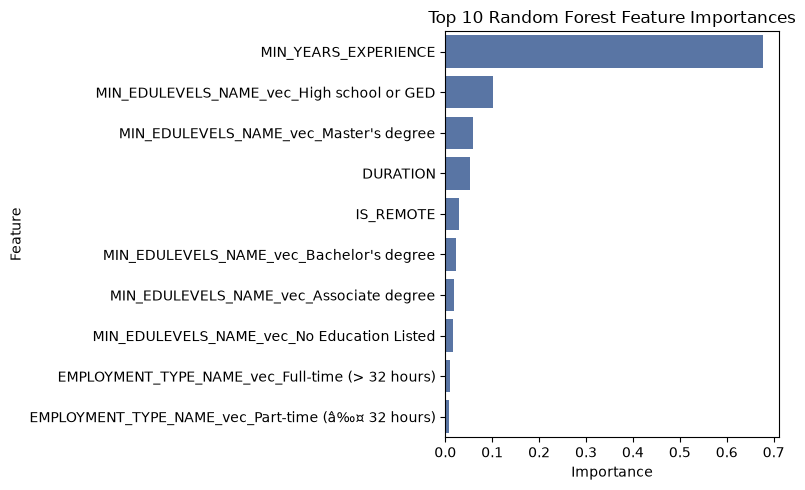

In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

rf_names = feature_names(data, "features")
importances = list(rf_model.featureImportances.toArray())

# Diagnostic check (lengths should match).
print("Length of feature names:", len(rf_names))
print("Length of importances:", len(importances))

importance_df = (pd.DataFrame({"Feature": rf_names, "Importance": importances})
                 .sort_values("Importance", ascending=False)
                 .head(10))

os.makedirs("_output", exist_ok=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#4C72B0")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("_output/rf_feature_importance.png", dpi=150)
plt.show()

The ranking confirms that the minimum years of experience is by far the dominant predictor of advertised salary, accounting for roughly two thirds of the total importance, which matches the strong and statistically significant coefficient seen in the earlier regression models. The minimum education level contributes the next largest share, while the posting duration and the remote indicator add only small amounts and the employment type and staffing indicators matter least. This agreement between the regression models and a very different tree based model gives extra confidence that experience is the main driver of pay in this data rather than an artefact of one modelling choice.

# Compare 3 Models – GLR, Polynomial, RF

With all three models trained we now compare them on the same held out test set. Generating predictions from each model on the identical test rows lets us judge them on a level field, since every model has seen exactly the same inputs and the same unseen cases. The root mean squared error is the one metric that is directly comparable across all three models, because it simply measures the typical prediction error in United States dollars regardless of how the model works internally. The Akaike and Bayesian information criteria are likelihood based scores that reward goodness of fit while penalising model complexity, and they are available for the two generalized linear models but not for the random forest, because a random forest is not a likelihood based model and therefore has no deviance or dispersion from which to compute them. We report those two criteria for the linear and polynomial models and mark them as not applicable for the random forest.

In [16]:
# Collect each model's test predictions into one long-format table: SALARY, Model, Predicted.
def to_pdf(spark_pred, label):
    pdf = spark_pred.select("SALARY", "prediction").toPandas()
    pdf["Model"] = label
    return pdf.rename(columns={"prediction": "Predicted"})

pred_long = pd.concat([
    to_pdf(lr_pred, "GLR"),
    to_pdf(poly_pred, "Polynomial"),
    to_pdf(rf_pred, "Random Forest"),
], ignore_index=True)

pred_long.head()

,SALARY,Predicted,Model
0,80250,107616.934124,GLR
1,67400,104595.318718,GLR
2,172026,171604.693552,GLR
3,197300,139804.626981,GLR
4,178500,156797.624927,GLR


## Calculating Log-Likelihood and BIC for PySpark Models

The Akaike information criterion is reported directly by the generalized linear model summary, but the Bayesian information criterion is not, so we build it from the model deviance. The log-likelihood, which measures how probable the observed salaries are under the fitted model, is recovered as negative one half times the quantity n times the natural log of two pi, plus n times the natural log of the dispersion, plus the deviance divided by the dispersion, where n is the number of training observations, the dispersion is the model variance estimate, and the deviance measures the unexplained variation. The Bayesian information criterion is then k times the natural log of n minus two times the log-likelihood, where k is the number of estimated parameters. Because the Bayesian criterion multiplies the parameter count by the natural log of the sample size rather than by two, it penalises extra parameters more heavily than the Akaike criterion does, so it favours simpler models more strongly. For both criteria a lower value indicates a better balance of fit and simplicity.

In [17]:
import math

def glm_log_likelihood(summary, n_obs):
    disp = summary.dispersion
    dev = summary.deviance
    return -0.5 * (n_obs * math.log(2 * math.pi) + n_obs * math.log(disp) + dev / disp)

def glm_bic(summary, n_obs, k_params):
    log_lik = glm_log_likelihood(summary, n_obs)
    return k_params * math.log(n_obs) - 2 * log_lik

n_obs = train_data.count()
lr_k = len(lr_model.coefficients) + 1
poly_k = len(poly_model.coefficients) + 1
lr_bic = glm_bic(train_sum, n_obs, lr_k)
poly_bic = glm_bic(poly_train_sum, n_obs, poly_k)

metrics = pd.DataFrame({
    "Model": ["GLR (Linear)", "Polynomial", "Random Forest"],
    "Test RMSE": [round(lr_rmse, 2), round(poly_rmse, 2), round(rf_rmse, 2)],
    "Test R2": [round(lr_r2, 4), round(poly_r2, 4), round(rf_r2, 4)],
    "AIC": [f"{train_sum.aic:,.2f}", f"{poly_train_sum.aic:,.2f}", "N/A"],
    "BIC": [f"{lr_bic:,.2f}", f"{poly_bic:,.2f}", "N/A"],
})
metrics

,Model,Test RMSE,Test R2,AIC,BIC
0,GLR (Linear),33687.69,0.3671,"274,851.98","274,938.30"
1,Polynomial,33419.70,0.3771,"274,693.59","274,787.26"
2,Random Forest,31431.08,0.4491,N/A,N/A


## Evaluation Metrics

The comparison table and the diagnostic plots below are read together. In the plots each point is one test posting, with its actual salary on the horizontal axis and the model's predicted salary on the vertical axis, and the red dashed line marks perfect prediction, so a model whose points hug that line more tightly is the more accurate one.

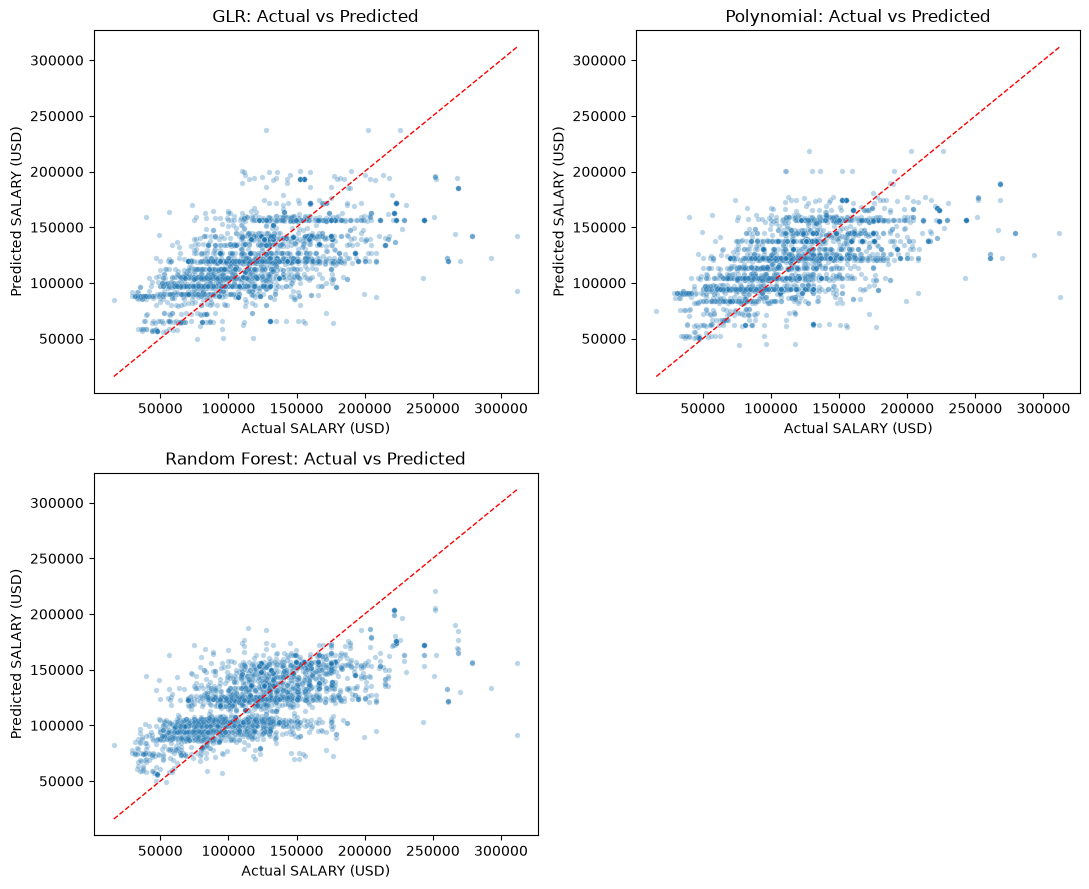

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["GLR", "Polynomial", "Random Forest"]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for ax, name in zip(axes, model_order):
    sub = pred_long[pred_long["Model"] == name]
    sns.scatterplot(data=sub, x="SALARY", y="Predicted", ax=ax, alpha=0.3, s=15)
    lo = min(sub["SALARY"].min(), sub["Predicted"].min())
    hi = max(sub["SALARY"].max(), sub["Predicted"].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual SALARY (USD)")
    ax.set_ylabel("Predicted SALARY (USD)")
axes[3].axis("off")
plt.tight_layout()
plt.savefig("_output/model_comparison.png", dpi=150)
plt.show()

The metrics and the plots agree on the ranking. The random forest gives the lowest root mean squared error and the highest test R squared of the three models, so it is the most accurate predictor of advertised salary on unseen postings, and its scatter of points sits closest to the perfect prediction line. Between the two generalized linear models the polynomial model has both the lower Akaike and the lower Bayesian information criterion, which confirms that the squared experience term earns its place rather than just adding complexity, and it also edges out the plain linear model on test error. The information criteria cannot rank the random forest because it has no likelihood, so the choice of best model depends on the goal. If the goal is the most accurate salary prediction then the random forest is the clear choice, while if the goal is an interpretable model with coefficients, significance tests, and information criteria for inference, then the polynomial generalized linear model is the preferred option. A practical workflow would use the polynomial model to explain which factors move salary and by how much, and the random forest to generate the most accurate point predictions.